# n-Tron switching threshold (step 1)

U1's gate switches from superconducting to resistive once the gate current
exceeds `Isw_g` or once a voltage condition we don't have yet is met, whichever comes first. 
This step only checks the current condition, so predicted crossing times are a lower bound on the real ones.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from S01_pulser import pulser1, pulser2
from S02_transmission_line import Td

t = np.linspace(0, 30e-9, 2000)

Rd = 10e3   # Ohms (R5/L3 branch)
i_Ld_ch1 = pulser1(t - Td) / Rd
i_Ld_ch2 = pulser2(t - Td) / Rd
from S04_nTron import Isw_g, find_threshold_crossings
print(f"Isw_g = {Isw_g*1e6:.3f} µA")

Isw_g = 8.998 µA


In [10]:
t_rise1, t_fall1 = find_threshold_crossings(t, i_Ld_ch1, Isw_g)
t_rise2, t_fall2 = find_threshold_crossings(t, i_Ld_ch2, Isw_g)
print(f"channel 1 (L3): rise {t_rise1*1e9:.2f} ns, fall {t_fall1*1e9:.2f} ns")
print(f"channel 2 (L9): rise {t_rise2*1e9:.2f} ns, fall {t_fall2*1e9:.2f} ns")

channel 1 (L3): rise 22.56 ns, fall 26.37 ns
channel 2 (L9): rise 7.05 ns, fall 10.87 ns


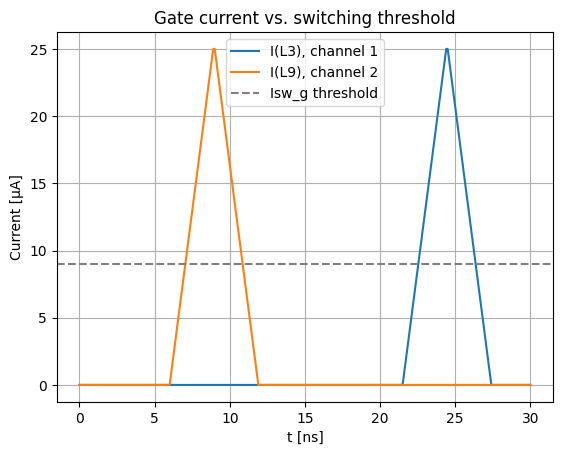

In [11]:
fig, ax = plt.subplots()
ax.plot(t * 1e9, i_Ld_ch1 * 1e6, label="I(L3), channel 1")
ax.plot(t * 1e9, i_Ld_ch2 * 1e6, label="I(L9), channel 2")
ax.axhline(Isw_g * 1e6, color='gray', linestyle='--', label="Isw_g threshold")
ax.set_xlabel("t [ns]")
ax.set_ylabel("Current [µA]")
ax.set_title("Gate current vs. switching threshold")
ax.legend()
ax.grid(True)
plt.show()